In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from stable_baselines3 import PPO
from stable_baselines3.common.vec_env import DummyVecEnv
from stable_baselines3.common.callbacks import EvalCallback, StopTrainingOnNoModelImprovement
# IMPORT THE SMART WRAPPER
from stable_baselines3.common.monitor import Monitor 
from rl_system import PortfolioEnv
import os

# 1. Configuration
DATA_PATH = 'advanced_portfolio_data.csv'
TICKERS = ['NVDA', 'MU', 'AAPL', 'AMD', 'ASML', 'MSFT', 'GOOG']
N_FOLDS = 3
GAP = 8 
REBALANCE_PERIOD = 4

# Load Data
df = pd.read_csv(DATA_PATH, index_col=0)
n_total = len(df)
test_split_idx = int(n_total * 0.8)
dev_df = df.iloc[:test_split_idx]
test_df = df.iloc[test_split_idx:]

segment_size = len(dev_df) // (N_FOLDS + 1)

# 3. Walk-Forward Loop
for i in range(N_FOLDS):
    print(f"\n=== STARTING FOLD {i+1}/{N_FOLDS} ===")
    
    train_end_idx = (i + 1) * segment_size
    val_start_idx = train_end_idx + GAP 
    val_end_idx = min((i + 2) * segment_size, len(dev_df))
    
    fold_train_df = dev_df.iloc[:train_end_idx]
    fold_val_df = dev_df.iloc[val_start_idx:val_end_idx]
    
    # --- FIX: ADD MONITOR WRAPPER ---
    # Monitor tracks the "True" episode reward and length for the logs
    env_train = DummyVecEnv([lambda: Monitor(PortfolioEnv(fold_train_df, TICKERS, rebalance_period=REBALANCE_PERIOD))])
    env_val = DummyVecEnv([lambda: Monitor(PortfolioEnv(fold_val_df, TICKERS, rebalance_period=REBALANCE_PERIOD))])
    
    fold_save_path = f"./logs/fold_{i+1}/"
    
    stop_callback = StopTrainingOnNoModelImprovement(max_no_improvement_evals=5, min_evals=3, verbose=1)
    
    eval_callback = EvalCallback(
        env_val,
        best_model_save_path=fold_save_path,
        log_path=fold_save_path,
        eval_freq=1024,
        deterministic=True,
        render=False,
        callback_after_eval=stop_callback
    )
    
    model = PPO(
        "MlpPolicy", 
        env_train, 
        verbose=0, 
        learning_rate=0.00025, 
        n_steps=2048, 
        batch_size=64,
        ent_coef=0.03, 
        gamma=0.95,
        tensorboard_log=f"./ppo_walk_forward_tb/"
    )
    
    print(f"Training Fold {i+1}...")
    model.learn(total_timesteps=80000, callback=eval_callback)
    
    best_fold_model = PPO.load(os.path.join(fold_save_path, "best_model"))
    print(f"Fold {i+1} finished. Best model saved.")

    if i == N_FOLDS - 1:
        print("\nSaving Final Fold Model...")
        os.makedirs("best_model", exist_ok=True)
        best_fold_model.save("best_model/best_model")
        print("Done.")

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
Users of this version of Gym should be able to simply replace 'import gym' with 'import gymnasium as gym' in the vast majority of cases.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.



=== STARTING FOLD 1/3 ===
Training Fold 1...
Eval num_timesteps=1024, episode_reward=13180.59 +/- 0.00
Episode length: 22.00 +/- 0.00
New best mean reward!
Eval num_timesteps=2048, episode_reward=13180.59 +/- 0.00
Episode length: 22.00 +/- 0.00
Eval num_timesteps=3072, episode_reward=13128.24 +/- 0.00
Episode length: 22.00 +/- 0.00
Eval num_timesteps=4096, episode_reward=13128.24 +/- 0.00
Episode length: 22.00 +/- 0.00
Eval num_timesteps=5120, episode_reward=13092.47 +/- 0.00
Episode length: 22.00 +/- 0.00
Eval num_timesteps=6144, episode_reward=13092.47 +/- 0.00
Episode length: 22.00 +/- 0.00
Eval num_timesteps=7168, episode_reward=13058.73 +/- 0.00
Episode length: 22.00 +/- 0.00
Eval num_timesteps=8192, episode_reward=13058.73 +/- 0.00
Episode length: 22.00 +/- 0.00
Eval num_timesteps=9216, episode_reward=13017.15 +/- 0.00
Episode length: 22.00 +/- 0.00
Stopping training because there was no new best model in the last 6 evaluations
Fold 1 finished. Best model saved.

=== STARTING FO

Loading evaluation logs...
TRAINING AUDIT SUMMARY REPORT

Fold 1:
  Total Evaluations: 9
  Best Reward: 13180.5946 (at step 1,024)
  Final Reward: 13017.1488 (at step 9,216)
  Performance Drop: 1.24%
  Evaluations After Peak: 8
  Status: STABLE

Fold 2:
  Total Evaluations: 21
  Best Reward: 18375.5619 (at step 15,360)
  Final Reward: 17911.3440 (at step 21,504)
  Performance Drop: 2.53%
  Evaluations After Peak: 6
  Status: STABLE

Fold 3:
  Total Evaluations: 41
  Best Reward: 6079.9266 (at step 35,840)
  Final Reward: 5798.8936 (at step 41,984)
  Performance Drop: 4.62%
  Evaluations After Peak: 6
  Status: STABLE

OVERALL STATISTICS

Average Best Reward: 12545.3610 +/- 5039.7291
Average Performance Drop: 2.80% +/- 1.39%
Average Evaluations After Peak: 6.7 +/- 0.9

Overfitting Assessment:
  Stable folds: 3/3
  Moderate overfitting: 0/3
  Severe overfitting: 0/3


Generating visualization plots...


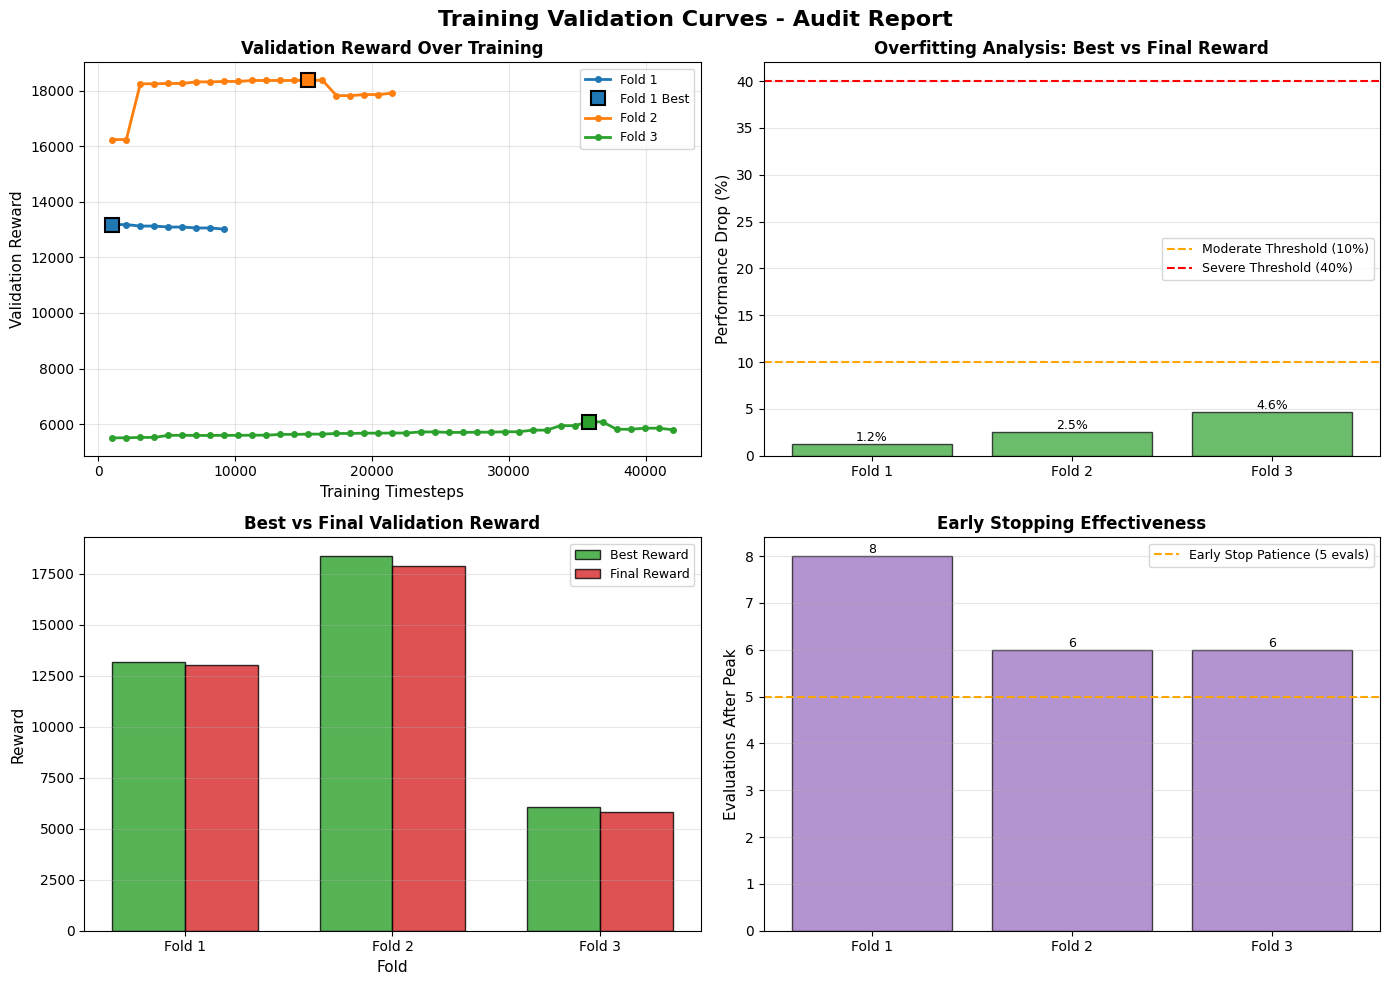

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import os

def load_evaluation_logs(logs_dir='./logs', n_folds=3):
    """
    Load evaluation logs from all folds.
    
    Returns:
        dict: {fold_idx: {'timesteps': array, 'rewards': array, 'ep_lengths': array}}
    """
    logs_dir = Path(logs_dir)
    eval_data = {}
    
    for fold_idx in range(1, n_folds + 1):
        fold_dir = logs_dir / f'fold_{fold_idx}'
        eval_file = fold_dir / 'evaluations.npz'
        
        if eval_file.exists():
            with np.load(eval_file) as data:
                timesteps = data['timesteps']
                results = data['results']  # Shape: (n_evals, n_episodes)
                ep_lengths = data.get('ep_lengths', None)
                
                # Calculate mean reward per evaluation
                mean_rewards = results.mean(axis=1)
                std_rewards = results.std(axis=1) if results.shape[1] > 1 else np.zeros_like(mean_rewards)
                
                eval_data[fold_idx] = {
                    'timesteps': timesteps,
                    'mean_rewards': mean_rewards,
                    'std_rewards': std_rewards,
                    'ep_lengths': ep_lengths,
                    'n_evals': len(timesteps)
                }
        else:
            print(f"Warning: No evaluation file found for fold {fold_idx}")
    
    return eval_data

def analyze_fold_performance(eval_data, fold_idx):
    """Analyze performance metrics for a single fold."""
    if fold_idx not in eval_data:
        return None
    
    data = eval_data[fold_idx]
    rewards = data['mean_rewards']
    timesteps = data['timesteps']
    
    best_idx = np.argmax(rewards)
    best_reward = rewards[best_idx]
    best_step = timesteps[best_idx]
    final_reward = rewards[-1]
    final_step = timesteps[-1]
    
    # Calculate performance drop
    if abs(best_reward) > 1e-6:
        drop_pct = (best_reward - final_reward) / abs(best_reward) * 100
    else:
        drop_pct = 0.0
    
    # Count evaluations after peak
    evals_after_peak = len(rewards) - best_idx - 1
    
    # Determine overfitting severity
    if drop_pct > 40:
        overfitting_status = 'severe'
    elif drop_pct > 10:
        overfitting_status = 'moderate'
    else:
        overfitting_status = 'stable'
    
    return {
        'best_reward': best_reward,
        'best_step': best_step,
        'final_reward': final_reward,
        'final_step': final_step,
        'drop_pct': drop_pct,
        'evals_after_peak': evals_after_peak,
        'overfitting_status': overfitting_status,
        'n_evals': len(rewards)
    }

def plot_training_curves(eval_data, save_path=None):
    """
    Plot validation curves for all folds with diagnostics.
    """
    n_folds = len(eval_data)
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle('Training Validation Curves - Audit Report', fontsize=16, fontweight='bold')
    
    # Colors for each fold
    colors = ['#1f77b4', '#ff7f0e', '#2ca02c']
    
    # Plot 1: Validation Reward Curves
    ax1 = axes[0, 0]
    for fold_idx in sorted(eval_data.keys()):
        data = eval_data[fold_idx]
        timesteps = data['timesteps']
        rewards = data['mean_rewards']
        std_rewards = data['std_rewards']
        color = colors[(fold_idx - 1) % len(colors)]
        
        # Plot mean reward
        ax1.plot(timesteps, rewards, 'o-', label=f'Fold {fold_idx}', 
                color=color, linewidth=2, markersize=4)
        
        # Plot std error bars if available
        if np.any(std_rewards > 0):
            ax1.fill_between(timesteps, rewards - std_rewards, rewards + std_rewards,
                           alpha=0.2, color=color)
        
        # Mark best point
        best_idx = np.argmax(rewards)
        ax1.plot(timesteps[best_idx], rewards[best_idx], 's', 
                color=color, markersize=10, markeredgecolor='black', markeredgewidth=1.5,
                label=f'Fold {fold_idx} Best' if fold_idx == 1 else '')
    
    ax1.set_xlabel('Training Timesteps', fontsize=11)
    ax1.set_ylabel('Validation Reward', fontsize=11)
    ax1.set_title('Validation Reward Over Training', fontsize=12, fontweight='bold')
    ax1.legend(loc='best', fontsize=9)
    ax1.grid(True, alpha=0.3)
    
    # Plot 2: Performance Drop Analysis
    ax2 = axes[0, 1]
    fold_indices = []
    drop_pcts = []
    colors_list = []
    
    for fold_idx in sorted(eval_data.keys()):
        analysis = analyze_fold_performance(eval_data, fold_idx)
        if analysis:
            fold_indices.append(f'Fold {fold_idx}')
            drop_pcts.append(analysis['drop_pct'])
            
            # Color code by severity
            if analysis['overfitting_status'] == 'severe':
                colors_list.append('#d62728')
            elif analysis['overfitting_status'] == 'moderate':
                colors_list.append('#ff7f0e')
            else:
                colors_list.append('#2ca02c')
    
    bars = ax2.bar(fold_indices, drop_pcts, color=colors_list, alpha=0.7, edgecolor='black')
    ax2.axhline(y=10, color='orange', linestyle='--', linewidth=1.5, label='Moderate Threshold (10%)')
    ax2.axhline(y=40, color='red', linestyle='--', linewidth=1.5, label='Severe Threshold (40%)')
    ax2.set_ylabel('Performance Drop (%)', fontsize=11)
    ax2.set_title('Overfitting Analysis: Best vs Final Reward', fontsize=12, fontweight='bold')
    ax2.legend(fontsize=9)
    ax2.grid(True, alpha=0.3, axis='y')
    
    # Add value labels on bars
    for bar, pct in zip(bars, drop_pcts):
        height = bar.get_height()
        ax2.text(bar.get_x() + bar.get_width()/2., height,
                f'{pct:.1f}%', ha='center', va='bottom' if height > 0 else 'top', fontsize=9)
    
    # Plot 3: Best vs Final Reward Comparison
    ax3 = axes[1, 0]
    x = np.arange(len(fold_indices))
    width = 0.35
    
    best_rewards = []
    final_rewards = []
    for fold_idx in sorted(eval_data.keys()):
        analysis = analyze_fold_performance(eval_data, fold_idx)
        if analysis:
            best_rewards.append(analysis['best_reward'])
            final_rewards.append(analysis['final_reward'])
    
    bars1 = ax3.bar(x - width/2, best_rewards, width, label='Best Reward', 
                   color='#2ca02c', alpha=0.8, edgecolor='black')
    bars2 = ax3.bar(x + width/2, final_rewards, width, label='Final Reward',
                   color='#d62728', alpha=0.8, edgecolor='black')
    
    ax3.set_xlabel('Fold', fontsize=11)
    ax3.set_ylabel('Reward', fontsize=11)
    ax3.set_title('Best vs Final Validation Reward', fontsize=12, fontweight='bold')
    ax3.set_xticks(x)
    ax3.set_xticklabels(fold_indices)
    ax3.legend(fontsize=9)
    ax3.grid(True, alpha=0.3, axis='y')
    
    # Plot 4: Evaluations After Peak
    ax4 = axes[1, 1]
    evals_after_peak = []
    for fold_idx in sorted(eval_data.keys()):
        analysis = analyze_fold_performance(eval_data, fold_idx)
        if analysis:
            evals_after_peak.append(analysis['evals_after_peak'])
    
    bars = ax4.bar(fold_indices, evals_after_peak, color='#9467bd', alpha=0.7, edgecolor='black')
    ax4.axhline(y=5, color='orange', linestyle='--', linewidth=1.5, 
               label='Early Stop Patience (5 evals)')
    ax4.set_ylabel('Evaluations After Peak', fontsize=11)
    ax4.set_title('Early Stopping Effectiveness', fontsize=12, fontweight='bold')
    ax4.legend(fontsize=9)
    ax4.grid(True, alpha=0.3, axis='y')
    
    # Add value labels
    for bar, count in zip(bars, evals_after_peak):
        height = bar.get_height()
        ax4.text(bar.get_x() + bar.get_width()/2., height,
                f'{int(count)}', ha='center', va='bottom', fontsize=9)
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f"Plot saved to {save_path}")
    
    return fig

def print_summary_report(eval_data):
    """Print a text summary of training performance."""
    print("=" * 80)
    print("TRAINING AUDIT SUMMARY REPORT")
    print("=" * 80)
    
    for fold_idx in sorted(eval_data.keys()):
        analysis = analyze_fold_performance(eval_data, fold_idx)
        if analysis:
            print(f"\nFold {fold_idx}:")
            print(f"  Total Evaluations: {analysis['n_evals']}")
            print(f"  Best Reward: {analysis['best_reward']:.4f} (at step {analysis['best_step']:,})")
            print(f"  Final Reward: {analysis['final_reward']:.4f} (at step {analysis['final_step']:,})")
            print(f"  Performance Drop: {analysis['drop_pct']:.2f}%")
            print(f"  Evaluations After Peak: {analysis['evals_after_peak']}")
            print(f"  Status: {analysis['overfitting_status'].upper()}")
    
    # Overall statistics
    print("\n" + "=" * 80)
    print("OVERALL STATISTICS")
    print("=" * 80)
    
    all_best_rewards = []
    all_drop_pcts = []
    all_evals_after_peak = []
    
    for fold_idx in sorted(eval_data.keys()):
        analysis = analyze_fold_performance(eval_data, fold_idx)
        if analysis:
            all_best_rewards.append(analysis['best_reward'])
            all_drop_pcts.append(analysis['drop_pct'])
            all_evals_after_peak.append(analysis['evals_after_peak'])
    
    if all_best_rewards:
        print(f"\nAverage Best Reward: {np.mean(all_best_rewards):.4f} +/- {np.std(all_best_rewards):.4f}")
        print(f"Average Performance Drop: {np.mean(all_drop_pcts):.2f}% +/- {np.std(all_drop_pcts):.2f}%")
        print(f"Average Evaluations After Peak: {np.mean(all_evals_after_peak):.1f} +/- {np.std(all_evals_after_peak):.1f}")
        
        # Overfitting assessment
        severe_count = sum(1 for pct in all_drop_pcts if pct > 40)
        moderate_count = sum(1 for pct in all_drop_pcts if 10 < pct <= 40)
        stable_count = sum(1 for pct in all_drop_pcts if pct <= 10)
        
        print(f"\nOverfitting Assessment:")
        print(f"  Stable folds: {stable_count}/{len(all_drop_pcts)}")
        print(f"  Moderate overfitting: {moderate_count}/{len(all_drop_pcts)}")
        print(f"  Severe overfitting: {severe_count}/{len(all_drop_pcts)}")
    
    print("\n" + "=" * 80)

# Main execution
if __name__ == "__main__":
    # Configuration
    LOGS_DIR = './logs'
    N_FOLDS = 3
    SAVE_PLOT = False
    PLOT_PATH = './training_curves_audit.png'
    
    # Load evaluation data
    print("Loading evaluation logs...")
    eval_data = load_evaluation_logs(LOGS_DIR, N_FOLDS)
    
    if not eval_data:
        print("Error: No evaluation data found. Make sure training has completed.")
    else:
        # Print summary report
        print_summary_report(eval_data)
        
        # Generate plots
        print("\nGenerating visualization plots...")
        plot_training_curves(eval_data, save_path=PLOT_PATH if SAVE_PLOT else None)
        
        plt.show()